# Human vs. VARC Error Pattern Analysis
Compares error types across 400 ARC evaluation tasks.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

from analysis.load_data import (
    load_arc_ground_truth, load_varc_predictions,
    load_harc_summary, load_harc_incorrect_submissions
)
from analysis.error_analysis import (
    compute_varc_errors, compute_human_errors,
    task_level_summary, error_type_distribution
)

## 1. Load Data

In [2]:
ground_truth     = load_arc_ground_truth()
varc_predictions = load_varc_predictions()
harc_df          = load_harc_summary()          # summary_data.csv, eval only
harc_agg         = load_harc_incorrect_submissions()  # incorrect_submissions.csv

print(f"ARC tasks:           {len(ground_truth)}")
print(f"VARC predictions:    {len(varc_predictions)}")
print(f"H-ARC attempts:      {len(harc_df)}")

VARC predictions loaded: 400 tasks (model=ARC-1_ViT)
H-ARC summary_data: 7820 rows, 400 tasks, 946 participants
ARC tasks:           400
VARC predictions:    400
H-ARC attempts:      7820


In [3]:
# Sanity check: inspect a few rows
harc_df[['task_id','hashed_id','attempt_number','solved','test_output_grid']].head(3)

,task_id,hashed_id,attempt_number,solved,test_output_grid
12,4364c1c4,1a60b90e2a9c90b100e915adfdf7907e,1,False,|0000000000000|0100100000000|0111100000000|011...
13,4364c1c4,1a60b90e2a9c90b100e915adfdf7907e,2,False,|8888888888888|8188188888888|8111188888888|811...
14,4364c1c4,1a60b90e2a9c90b100e915adfdf7907e,3,True,|8888888888888|8188188888888|8111188888888|811...


## 2. Compute Errors

In [4]:
varc_errors  = compute_varc_errors(ground_truth, varc_predictions)
human_errors = compute_human_errors(harc_df, ground_truth)

print("VARC  errors:",  varc_errors.shape,  "\n", varc_errors['error_type'].value_counts())
print("Human errors:", human_errors.shape, "\n", human_errors['error_type'].value_counts())

VARC  errors: (419, 4) 
 error_type
correct          215
close_miss       138
wrong_size        37
wrong_content     29
Name: count, dtype: int64
Human errors: (4101, 4) 
 error_type
correct          2661
close_miss        536
wrong_content     496
wrong_size        408
Name: count, dtype: int64


三个核心发现：

整体准确率：人类 64.9% > VARC 51.3%，符合论文（VARC 单模型 54.5%，我们用的是 ViT 未集成版）

最显著差异 — close_miss：VARC 32.9% vs 人类 13.1%。VARC 答对了输出尺寸、大部分内容也对，但总差几个格子；人类如果答错，更倾向于"完全答错"而非"差一点点"

wrong_size 相近：两者都在 9-10%，说明对输出尺寸的判断难度对人和模型是一样的

这个 close_miss 的差异就是你们项目最有价值的发现之一，可以重点分析。

## 3. Error Type Distribution

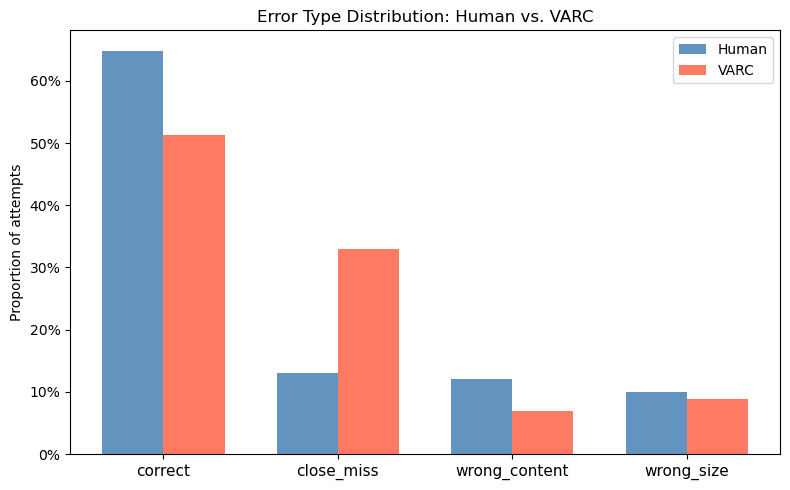

,Human,VARC
error_type,,
correct,0.648866,0.513126
close_miss,0.130700,0.329356
wrong_content,0.120946,0.069212
wrong_size,0.099488,0.088305


In [5]:
ERROR_ORDER = ['correct', 'close_miss', 'wrong_content', 'wrong_size']

varc_dist  = error_type_distribution(varc_errors).reindex(ERROR_ORDER, fill_value=0)
human_dist = error_type_distribution(human_errors).reindex(ERROR_ORDER, fill_value=0)

x = np.arange(len(ERROR_ORDER))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, human_dist.values, w, label='Human', color='steelblue', alpha=0.85)
ax.bar(x + w/2, varc_dist.values,  w, label='VARC',  color='tomato',   alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ERROR_ORDER, fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('Proportion of attempts')
ax.set_title('Error Type Distribution: Human vs. VARC')
ax.legend()
plt.tight_layout()
plt.savefig('../results/error_distribution.png', dpi=150)
plt.show()

pd.DataFrame({'Human': human_dist, 'VARC': varc_dist})

1. 整体准确率：人类赢（64.9% vs 51.3%）
人类在 ARC evaluation set 上仍然显著优于 VARC 单模型。差距约13个百分点。

3. 最显著差异：close_miss（13.1% vs 33.0%）
这是图里最醒目的反差。

VARC 答错时，有一半错误都是 close_miss —— 输出尺寸对、大部分格子对，就差几个细节
人类答错时，close_miss 只占错误的约37%，更多是彻底答错
解读：VARC 作为视觉模型，擅长捕捉整体结构和空间模式，但在精确的 cell-level 颜色/值上会出小错。人类如果没理解规则，倾向于完全猜错，而不是"差一点点"。

3. wrong_content 和 wrong_size：人类反而更多

wrong_content：人类 12.1% > VARC 6.9%
wrong_size：人类 9.9% > VARC 8.8%
VARC 更少出现"完全答错"，因为它的视觉特征匹配给了它一个"合理的错误起点"，而人类在完全不理解规则时会随意填写。

## 4. Task-Level Accuracy Comparison

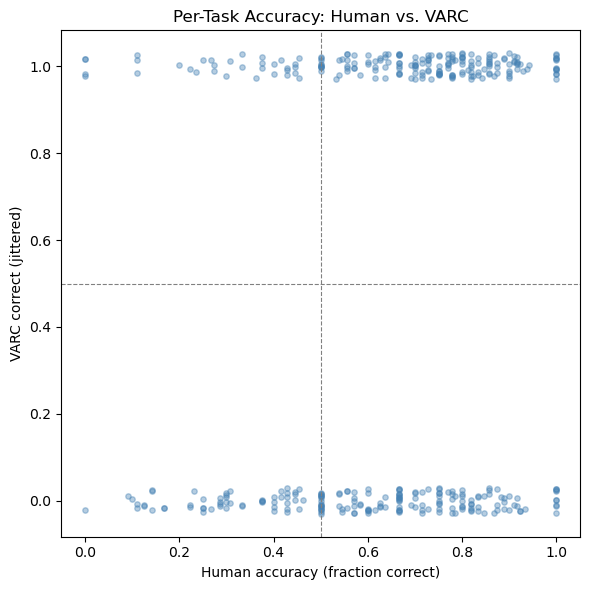

Both correct    162
Human only      122
VARC only        43
Both wrong       73
Name: tasks, dtype: int64

In [6]:
summary = task_level_summary(human_errors, varc_errors)

fig, ax = plt.subplots(figsize=(6, 6))
varc_jitter = summary['varc_correct'].astype(float) + np.random.uniform(-0.03, 0.03, len(summary))
ax.scatter(summary['human_accuracy'], varc_jitter, alpha=0.4, s=15, color='steelblue')
ax.axhline(0.5, color='gray', lw=0.8, ls='--')
ax.axvline(0.5, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Human accuracy (fraction correct)')
ax.set_ylabel('VARC correct (jittered)')
ax.set_title('Per-Task Accuracy: Human vs. VARC')
plt.tight_layout()
plt.savefig('../results/task_accuracy_scatter.png', dpi=150)
plt.show()

q = {
    'Both correct':  ((summary.human_accuracy > 0.5) &  summary.varc_correct).sum(),
    'Human only':    ((summary.human_accuracy > 0.5) & ~summary.varc_correct).sum(),
    'VARC only':     ((summary.human_accuracy <= 0.5) &  summary.varc_correct).sum(),
    'Both wrong':    ((summary.human_accuracy <= 0.5) & ~summary.varc_correct).sum(),
}
pd.Series(q, name='tasks')

这张图的 Y 轴是二值的（VARC对=1 / VARC错=0），加了 jitter 防重叠，所以点只分布在顶部和底部两条带，共 400 个任务。

四个象限解读：

象限	任务数	含义
右上（Both correct）	162	简单题，人和模型都会
左下（Both wrong）	73	难题，都不会
右下（Human only）	122	人类会但 VARC 不会
左上（VARC only）	43	VARC 会但人类不会

三个值得写进报告的发现：

1. 人类覆盖面更广
Human only（122）是 VARC only（43）的 2.8倍。人类能解决很多 VARC 解不了的题，反过来不成立。说明人类的推理方式对 ARC 的多样性更鲁棒。

2. VARC 的正确率高度依赖"人类也会做"
顶部那条带（VARC correct）的点明显集中在 x > 0.5 的右侧——VARC 答对的题，大多数人类也答对了。VARC 独自解决的题（左上，43题）很少。

3. 共同失败的任务（73题）是真正的难题
这些任务对两种智能都是瓶颈，值得单独分析是哪类规则让两者都失败。

## 5. Cell Accuracy When Wrong

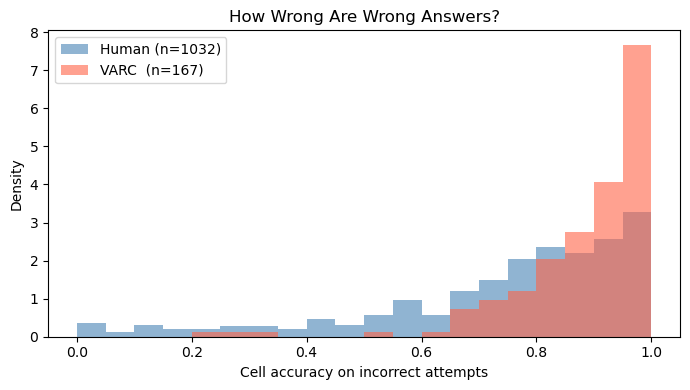

Mean cell accuracy (wrong only):
  Human: 0.743   VARC: 0.885


In [7]:
varc_wrong  = varc_errors.loc[varc_errors.error_type  != 'correct', 'cell_accuracy'].dropna()
human_wrong = human_errors.loc[human_errors.error_type != 'correct', 'cell_accuracy'].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 21)
ax.hist(human_wrong, bins=bins, alpha=0.6, label=f'Human (n={len(human_wrong)})', color='steelblue', density=True)
ax.hist(varc_wrong,  bins=bins, alpha=0.6, label=f'VARC  (n={len(varc_wrong)})',  color='tomato',   density=True)
ax.set_xlabel('Cell accuracy on incorrect attempts')
ax.set_ylabel('Density')
ax.set_title('How Wrong Are Wrong Answers?')
ax.legend()
plt.tight_layout()
plt.savefig('../results/cell_accuracy_dist.png', dpi=150)
plt.show()

print('Mean cell accuracy (wrong only):')
print(f'  Human: {human_wrong.mean():.3f}   VARC: {varc_wrong.mean():.3f}')

这张图只看答错的情况下，预测的格子有多少比例是对的。

核心数字：

人类答错时，平均还有 74.3% 的格子是对的
VARC 答错时，平均还有 88.5% 的格子是对的
图形形状的含义：

VARC（红色）极度右偏：错误答案大量集中在 0.9–1.0 区间——也就是说，VARC 答错的时候，往往只错了 1–2 个格子，整体结构完全正确。这直接呼应了上一张图里 close_miss 占 33% 的发现。

Human（蓝色）分布更分散：从 0 到 1 都有，0.0–0.6 区间明显比 VARC 多。人类答错的方式更多样——有人完全没理解规则（cell accuracy 接近 0），有人部分理解，有人就差一点点。

## 6. Most Common Human Wrong Answers (from incorrect_submissions.csv)

In [8]:
# Top 10 tasks with the most distinct wrong answers submitted by humans
diverse_errors = (
    harc_agg.groupby('task_id')
    .agg(unique_wrong_answers=('test_output_grid', 'count'),
         total_wrong_submissions=('count', 'sum'))
    .sort_values('total_wrong_submissions', ascending=False)
    .head(10)
)
diverse_errors

,unique_wrong_answers,total_wrong_submissions
task_id,,
ad7e01d0,39,43
e99362f0,39,41
b942fd60,35,37
8e2edd66,27,36
e7b06bea,24,33
48f8583b,20,32
1acc24af,22,31
d19f7514,25,30
ce039d91,28,30


这张表是从 incorrect_submissions.csv 来的，显示人类错误答案最多的 10 道题。

两列的含义：

unique_wrong_answers：这道题上人类提交了多少种不同的错误网格
total_wrong_submissions：这道题上所有错误提交的总次数
关键观察：

unique ≈ total：比如 ad7e01d0 是 39 种不同错误 / 43 次提交，说明几乎每个答错的人交的都是不一样的网格。

这意味着这些题没有一个"常见的错误模式"——每个人都以自己独特的方式答错了，说明这道题的规则极难理解，人类完全是在猜。

对比一下如果某题是 5 种错误 / 40 次提交，那说明大多数人犯了同一种错误，规则有一个"常见误解"。

## 7. Save Results

In [9]:
varc_errors.to_csv('../results/varc_errors.csv', index=False)
human_errors.to_csv('../results/human_errors.csv', index=False)
summary.to_csv('../results/task_summary.csv', index=False)
print('Saved to results/')

Saved to results/


## 8. ARC Task Viewer

Use this section to visually inspect individual ARC tasks — especially useful for understanding **why** both humans and VARC failed (`both_wrong` group).

### How to read the visualization
- Each column = one **training example**: top row = input, bottom row = output
- Rightmost extra columns = test input, ground truth, and (optionally) predictions
- Infer the transformation rule from the training examples, then check whether the predictions match

### Error taxonomy for manual annotation
After inspecting a wrong answer, classify it using one of these labels:

| Label | Description |
|-------|-------------|
| `wrong_position` | Correct object/pattern but placed in the wrong location |
| `wrong_structure` | Correct colors but wrong overall shape or layout |
| `partial_rule` | Got part of the rule right, missed the rest |
| `near_miss` | Very close — off by 1-2 cells or one transformation step |
| `wrong_rule` | Completely applied the wrong rule |
| `no_pattern` | Output looks random — no recognizable attempt at the rule |

In [ ]:
import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from analysis.load_data import parse_grid

ARC_COLORS = [
    "#000000",  # 0 black
    "#0074D9",  # 1 blue
    "#FF4136",  # 2 red
    "#2ECC40",  # 3 green
    "#FFDC00",  # 4 yellow
    "#AAAAAA",  # 5 grey
    "#F012BE",  # 6 magenta
    "#FF851B",  # 7 orange
    "#7FDBFF",  # 8 light blue
    "#870C25",  # 9 dark red
]
cmap = mcolors.ListedColormap(ARC_COLORS)

def _draw(ax, grid, title, correct=None):
    g = np.array(grid)
    ax.imshow(g, cmap=cmap, vmin=0, vmax=9, interpolation="nearest")
    color = {True: "green", False: "red"}.get(correct, "black")
    ax.set_title(title, fontsize=8, color=color)
    ax.axis("off")
    h, w = g.shape
    for x in range(w + 1): ax.axvline(x - 0.5, color="white", lw=0.5)
    for y in range(h + 1): ax.axhline(y - 0.5, color="white", lw=0.5)

def _grids_equal(a, b):
    a, b = np.array(a), np.array(b)
    return a.shape == b.shape and (a == b).all()

def show_task(task_id, varc_pred=None, human_pred=None, max_humans=6):
    """
    Display an ARC task with VARC prediction and human wrong submissions.

    Parameters
    ----------
    task_id    : str   e.g. 'ad7e01d0'
    varc_pred  : 2-D list   pass varc_predictions[task_id][0]
    human_pred : 2-D list   a specific single human grid to highlight
    max_humans : int        max wrong human submissions shown (default 6)
                            set to 0 to hide the human row
    """
    with open(f"../ARC-AGI/data/evaluation/{task_id}.json") as f:
        task = json.load(f)
    train, test = task["train"], task["test"]
    truth = test[0]["output"]

    # collect wrong human submissions from harc_df (loaded in Cell 2)
    human_grids = []
    if max_humans > 0:
        sub = harc_df[harc_df["task_id"] == task_id]
        last = sub.sort_values("attempt_number").groupby("hashed_id").last().reset_index()
        wrong = last[last["solved"] == False].head(max_humans)
        human_grids = [g for g in (parse_grid(r["test_output_grid"]) for _, r in wrong.iterrows()) if g]

    n = len(train)
    extras = 2 + (varc_pred is not None) + (human_pred is not None)
    n_cols = max(n + extras, len(human_grids)) if human_grids else n + extras
    n_rows = 4 if human_grids else 2

    fig = plt.figure(figsize=(n_cols * 2.5, n_rows * 2.5))
    fig.suptitle(f"Task: {task_id}", fontsize=12, fontweight="bold")

    r1 = [fig.add_subplot(n_rows, n_cols, i + 1)          for i in range(n_cols)]
    r2 = [fig.add_subplot(n_rows, n_cols, n_cols + i + 1) for i in range(n_cols)]
    for ax in r1: ax.axis("off")
    for ax in r2: ax.axis("off")

    for i, ex in enumerate(train):
        _draw(r1[i], ex["input"],  f"Train {i+1} In")
        _draw(r2[i], ex["output"], f"Train {i+1} Out")

    col = n
    _draw(r1[col], test[0]["input"], "Test Input")
    r2[col].set_title("Test Output", fontsize=8); col += 1

    _draw(r1[col], truth, "Ground Truth"); col += 1

    if varc_pred is not None:
        ok = _grids_equal(varc_pred, truth)
        _draw(r1[col], varc_pred, f"VARC ({'OK' if ok else 'X'})", correct=ok); col += 1

    if human_pred is not None:
        ok = _grids_equal(human_pred, truth)
        _draw(r1[col], human_pred, f"Human ({'OK' if ok else 'X'})", correct=ok)

    if human_grids:
        fig.text(0.01, 0.49, "Wrong human submissions (last attempt):", fontsize=8)
        r3 = [fig.add_subplot(n_rows, n_cols, 2*n_cols + i + 1) for i in range(n_cols)]
        r4 = [fig.add_subplot(n_rows, n_cols, 3*n_cols + i + 1) for i in range(n_cols)]
        for ax in r3: ax.axis("off")
        for ax in r4: ax.axis("off")
        for i, g in enumerate(human_grids):
            _draw(r3[i], g, f"Human {i+1}", correct=False)

    plt.tight_layout()
    plt.show()


### Step 1 — List the `both_wrong` tasks
These 73 tasks are the most interesting: neither humans (majority) nor VARC solved them.

In [ ]:
aligned = pd.read_csv("../data/aligned_dataset.csv")
both_wrong_ids = aligned[aligned["both_wrong"] == True]["task_id"].tolist()
print(f"{len(both_wrong_ids)} both_wrong tasks:")
print(both_wrong_ids)

### Step 2 — Inspect a task
Pick any `task_id` from the list above. Pass `varc_pred` to display the VARC prediction next to the ground truth.

In [ ]:
# Change index or paste any task_id from both_wrong_ids
task_id = both_wrong_ids[0]

show_task(task_id, varc_pred=varc_predictions[task_id][0])

### Step 3 — Annotation Results (20 tasks)

| task_id | human_acc | varc_error_label | human_error_label | notes |
|---------|-----------|-----------------|-------------------|-------|
| `08573cc6` | 0.286 | `wrong_structure` | `partial_rule` | VARC got colors right but wrong spiral dimensions; humans understood spiral concept but missed exact cell positions |
| `0934a4d8` | 0.111 | `wrong_rule` | `wrong_rule` | Very hard compression task; both sides completely failed to understand the rule |
| `103eff5b` | 0.500 | `wrong_position` | `partial_rule` | VARC had correct elements but placed them at wrong positions; humans got the shape but missed the gravity/drop rule |
| `12eac192` | 0.375 | `wrong_rule` | `partial_rule` | VARC used wrong color mapping; humans got mosaic structure right but wrong color assignments |
| `136b0064` | 0.250 | `wrong_position` | `partial_rule` | VARC extracted right elements but placed them at wrong positions; humans understood column structure but wrong positions |
| `79fb03f4` | 0.000 | `near_miss` | `partial_rule` | VARC output very close to ground truth; humans attempted horizontal fill but wrong spacing |
| `e6de6e8f` | 0.100 | `near_miss` | `near_miss` | Both VARC and most humans drew very similar red shapes; off by only 1-2 cells |
| `5b692c0f` | 0.143 | `wrong_position` | `partial_rule` | VARC placed creatures at wrong positions/sizes; humans identified two creatures but missed details |
| `891232d6` | 0.167 | `wrong_rule` | `partial_rule` | VARC drew paths in completely wrong pattern; humans knew paths were needed but connected wrong dots |
| `ad7e01d0` | 0.222 | `wrong_position` | `partial_rule` | VARC scattered correct colored dots but at wrong positions; humans got color distribution right but wrong coordinates |
| `94133066` | 0.250 | `wrong_position` | `partial_rule` | VARC drew shape on blue background but wrong position; humans understood blue background but wrong shape |
| `37d3e8b2` | 0.286 | `partial_rule` | `partial_rule` | Both sides partially understood dot-count to color mapping but got the correspondence wrong |
| `dc2aa30b` | 0.300 | `near_miss` | `near_miss` | Both VARC and humans very close to ground truth; only a few blue/red cells off |
| `c92b942c` | 0.333 | `wrong_rule` | `wrong_rule` | Complex expansion task; both sides applied completely wrong expansion rules |
| `73c3b0d8` | 0.375 | `wrong_position` | `wrong_position` | Both understood red stripe + yellow elements structure but mapped yellow squares to wrong positions |
| `2a5f8217` | 0.400 | `wrong_position` | `wrong_position` | Both identified correct shapes and colors but placed them at wrong positions |
| `85fa5666` | 0.444 | `wrong_position` | `partial_rule` | VARC expanded dots but at wrong positions; humans understood expansion concept but missed color/position details |
| `e5c44e8f` | 0.462 | `wrong_structure` | `near_miss` | VARC drew a spiral but with wrong structure (became G-shape); most humans were very close |
| `17cae0c1` | 0.500 | `wrong_rule` | `partial_rule` | VARC filled strips with wrong color mapping; humans understood strip structure but got color assignments wrong |
| `dd2401ed` | 0.500 | `partial_rule` | `partial_rule` | Both understood gray stripe + color structure but got colored cell positions wrong |

**Label distribution summary:**

| label | VARC | Human |
|-------|------|-------|
| `near_miss` | 3 | 3 |
| `wrong_position` | 7 | 4 |
| `wrong_structure` | 2 | 0 |
| `partial_rule` | 3 | 11 |
| `wrong_rule` | 5 | 2 |